In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display

# 머신러닝
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances

# XGBoost
from xgboost import XGBClassifier

import time
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv("train.csv")
snp_info = pd.read_csv("snp_info.csv")

print("train 데이터 크기:", df.shape)
print("SNP 정보 데이터 크기:", snp_info.shape)



display(df.head())
display(snp_info.head())
print(df.info())

train 데이터 크기: (262, 21)
SNP 정보 데이터 크기: (15, 5)


,id,father,mother,gender,trait,SNP_01,SNP_02,SNP_03,SNP_04,SNP_05,...,SNP_07,SNP_08,SNP_09,SNP_10,SNP_11,SNP_12,SNP_13,SNP_14,SNP_15,class
0,TRAIN_000,0,0,0,2,G G,A G,A A,G A,C A,...,A A,G G,A A,G G,A G,A A,A A,A A,A A,B
1,TRAIN_001,0,0,0,2,A G,A G,C A,A A,A A,...,A A,G A,A A,A G,A A,G A,G G,A A,A A,C
2,TRAIN_002,0,0,0,2,G G,G G,A A,G A,C C,...,A A,G A,G A,A G,A A,A A,A A,A A,A A,B
3,TRAIN_003,0,0,0,1,A A,G G,A A,G A,A A,...,G G,A A,G G,A G,G G,G G,G G,A A,G G,A
4,TRAIN_004,0,0,0,2,G G,G G,C C,A A,C C,...,A A,A A,A A,G G,A A,A A,A G,A A,G A,C


,SNP_id,name,chrom,cm,pos
0,SNP_01,BTA-19852-no-rs,2,67.0546,42986890
1,SNP_02,ARS-USMARC-Parent-DQ647190-rs29013632,6,31.1567,13897068
2,SNP_03,ARS-BFGL-NGS-117009,6,68.2892,44649549
3,SNP_04,ARS-BFGL-NGS-60567,6,77.8749,53826064
4,SNP_05,BovineHD0600017032,6,80.5015,61779512


<class 'pandas.DataFrame'>
RangeIndex: 262 entries, 0 to 261
Data columns (total 21 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      262 non-null    str  
 1   father  262 non-null    int64
 2   mother  262 non-null    int64
 3   gender  262 non-null    int64
 4   trait   262 non-null    int64
 5   SNP_01  262 non-null    str  
 6   SNP_02  262 non-null    str  
 7   SNP_03  262 non-null    str  
 8   SNP_04  262 non-null    str  
 9   SNP_05  262 non-null    str  
 10  SNP_06  262 non-null    str  
 11  SNP_07  262 non-null    str  
 12  SNP_08  262 non-null    str  
 13  SNP_09  262 non-null    str  
 14  SNP_10  262 non-null    str  
 15  SNP_11  262 non-null    str  
 16  SNP_12  262 non-null    str  
 17  SNP_13  262 non-null    str  
 18  SNP_14  262 non-null    str  
 19  SNP_15  262 non-null    str  
 20  class   262 non-null    str  
dtypes: int64(4), str(17)
memory usage: 43.1 KB
None


In [26]:
snp_cols = [f"SNP_{i:02d}" for i in range(1, 16)]

print("SNP 컬럼:" , snp_cols)

SNP 컬럼: ['SNP_01', 'SNP_02', 'SNP_03', 'SNP_04', 'SNP_05', 'SNP_06', 'SNP_07', 'SNP_08', 'SNP_09', 'SNP_10', 'SNP_11', 'SNP_12', 'SNP_13', 'SNP_14', 'SNP_15']


In [27]:
# 공백 제거
for col in snp_cols:
    df[col] = df[col].str.replace(" ", "", regex=False)

for col in snp_cols:
    print(col, df[col].unique())

SNP_01 <StringArray>
['GG', 'AG', 'AA']
Length: 3, dtype: str
SNP_02 <StringArray>
['AG', 'GG', 'AA']
Length: 3, dtype: str
SNP_03 <StringArray>
['AA', 'CA', 'CC']
Length: 3, dtype: str
SNP_04 <StringArray>
['GA', 'AA', 'GG']
Length: 3, dtype: str
SNP_05 <StringArray>
['CA', 'AA', 'CC']
Length: 3, dtype: str
SNP_06 <StringArray>
['AA', 'AG', 'GG']
Length: 3, dtype: str
SNP_07 <StringArray>
['AA', 'GG', 'GA']
Length: 3, dtype: str
SNP_08 <StringArray>
['GG', 'GA', 'AA']
Length: 3, dtype: str
SNP_09 <StringArray>
['AA', 'GA', 'GG']
Length: 3, dtype: str
SNP_10 <StringArray>
['GG', 'AG', 'AA']
Length: 3, dtype: str
SNP_11 <StringArray>
['AG', 'AA', 'GG']
Length: 3, dtype: str
SNP_12 <StringArray>
['AA', 'GA', 'GG']
Length: 3, dtype: str
SNP_13 <StringArray>
['AA', 'GG', 'AG']
Length: 3, dtype: str
SNP_14 <StringArray>
['AA', 'CC', 'CA']
Length: 3, dtype: str
SNP_15 <StringArray>
['AA', 'GG', 'GA']
Length: 3, dtype: str


In [28]:
# SNP genotype 전처리
for col in snp_cols:
    
    # 2. 순서가 반대인 genotype 통일
    df[col] = df[col].replace({
        "AG": "GA"
    })

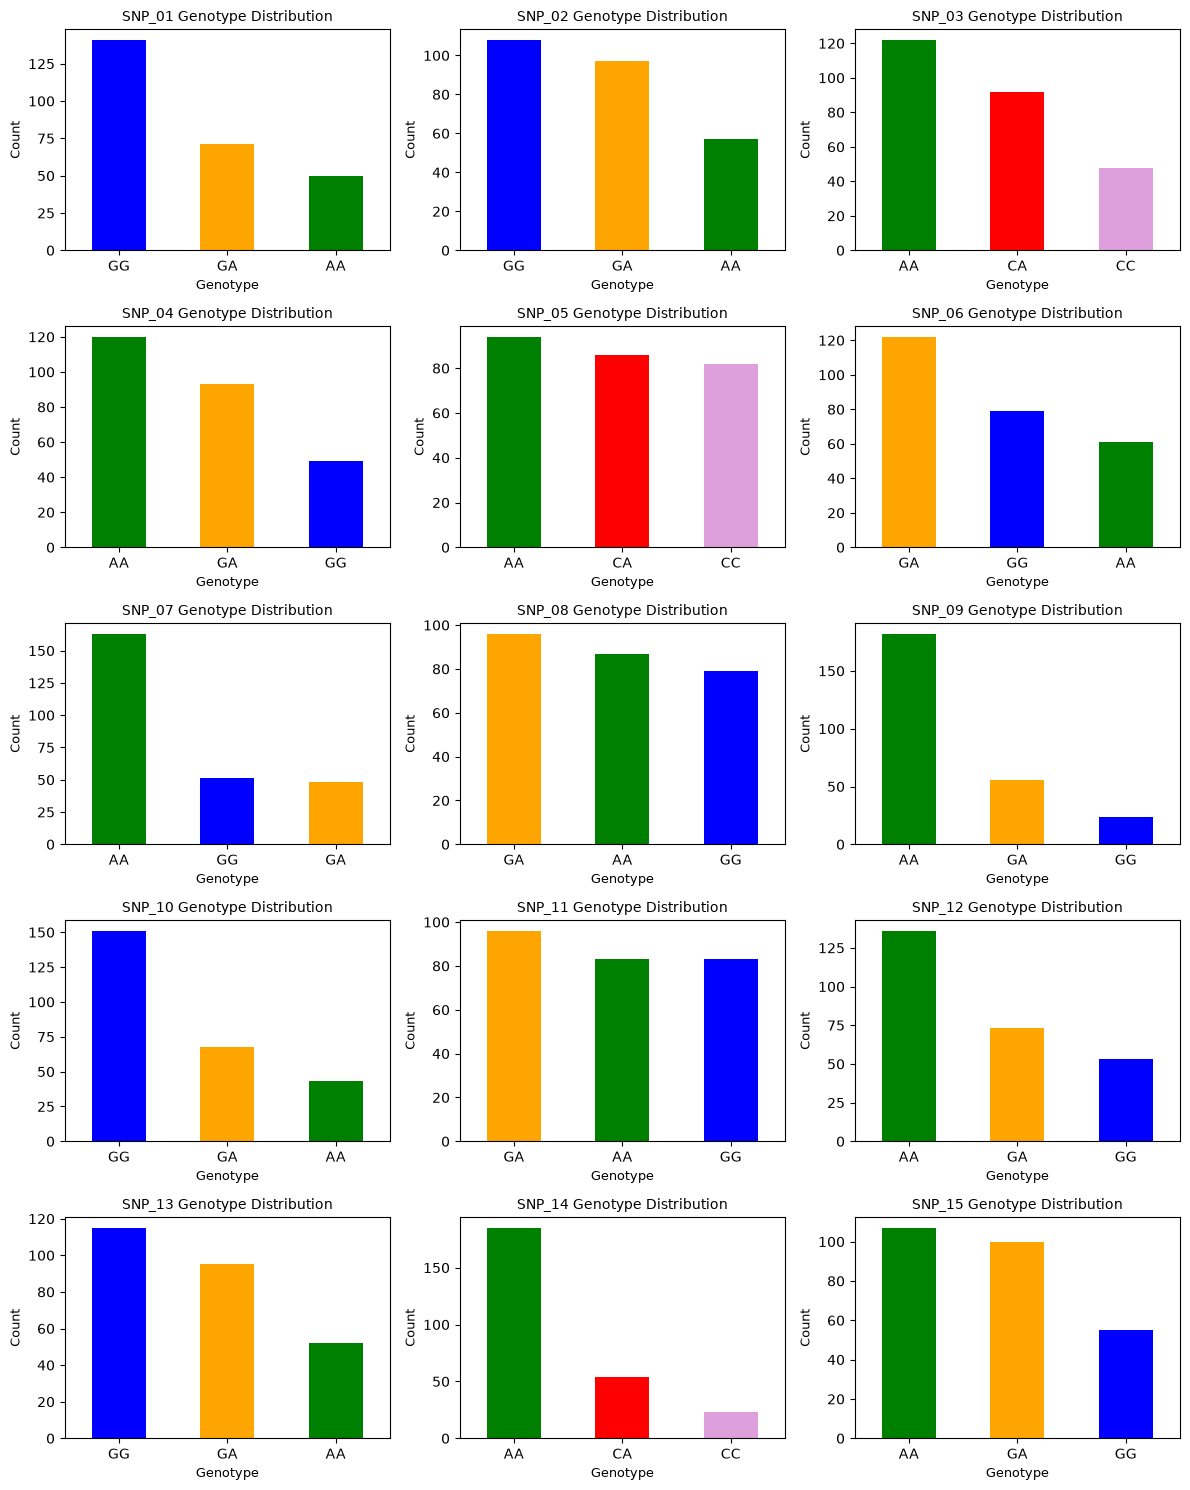

In [29]:
import matplotlib.pyplot as plt

# 유전자형별 색상 고정
genotype_colors = {
    "GG": "blue",
    "GA": "orange",
    "AA": "green",
    "CA": "red",
    "CC": "plum"
}

# 그래프 배치
n_cols = 3
n_rows = (len(snp_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(12, n_rows * 3)
)

axes = axes.flatten()

for i, col in enumerate(snp_cols):

    counts = df[col].value_counts()

    # 각 genotype에 해당하는 색상 적용
    colors = [
        genotype_colors.get(genotype, "gray")
        for genotype in counts.index
    ]

    counts.plot(
        kind="bar",
        ax=axes[i],
        color=colors
    )

    axes[i].set_title(f"{col} Genotype Distribution", fontsize=10)
    axes[i].set_xlabel("Genotype", fontsize=9)
    axes[i].set_ylabel("Count", fontsize=9)
    axes[i].tick_params(axis="x", rotation=0)

# 남는 그래프 칸 제거
for i in range(len(snp_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [30]:
for col in snp_cols:
    
    table = pd.crosstab(
        df[col],
        df["class"],
        normalize="columns"
    ) * 100
    
    display(table.round(2))

class,A,B,C
SNP_01,,,
AA,65.22,0.00,6.33
GA,30.43,21.93,31.65
GG,4.35,78.07,62.03


class,A,B,C
SNP_02,,,
AA,0.0,16.67,48.10
GA,8.7,50.88,41.77
GG,91.3,32.46,10.13


class,A,B,C
SNP_03,,,
AA,100.0,21.05,36.71
CA,0.0,51.75,41.77
CC,0.0,27.19,21.52


class,A,B,C
SNP_04,,,
AA,2.90,42.11,88.61
GA,44.93,46.49,11.39
GG,52.17,11.40,0.00


class,A,B,C
SNP_05,,,
AA,79.71,6.14,40.51
CA,20.29,30.70,46.84
CC,0.00,63.16,12.66


...

class,A,B,C
SNP_11,,,
AA,0.00,30.70,60.76
GA,18.84,48.25,35.44
GG,81.16,21.05,3.80


class,A,B,C
SNP_12,,,
AA,1.45,68.42,72.15
GA,28.99,28.07,26.58
GG,69.57,3.51,1.27


class,A,B,C
SNP_13,,,
AA,0.00,37.72,11.39
GA,4.35,46.49,49.37
GG,95.65,15.79,39.24


class,A,B,C
SNP_14,,,
AA,15.94,100.0,75.95
CA,53.62,0.0,21.52
CC,30.43,0.0,2.53


class,A,B,C
SNP_15,,,
AA,5.80,62.28,40.51
GA,30.43,35.09,49.37
GG,63.77,2.63,10.13


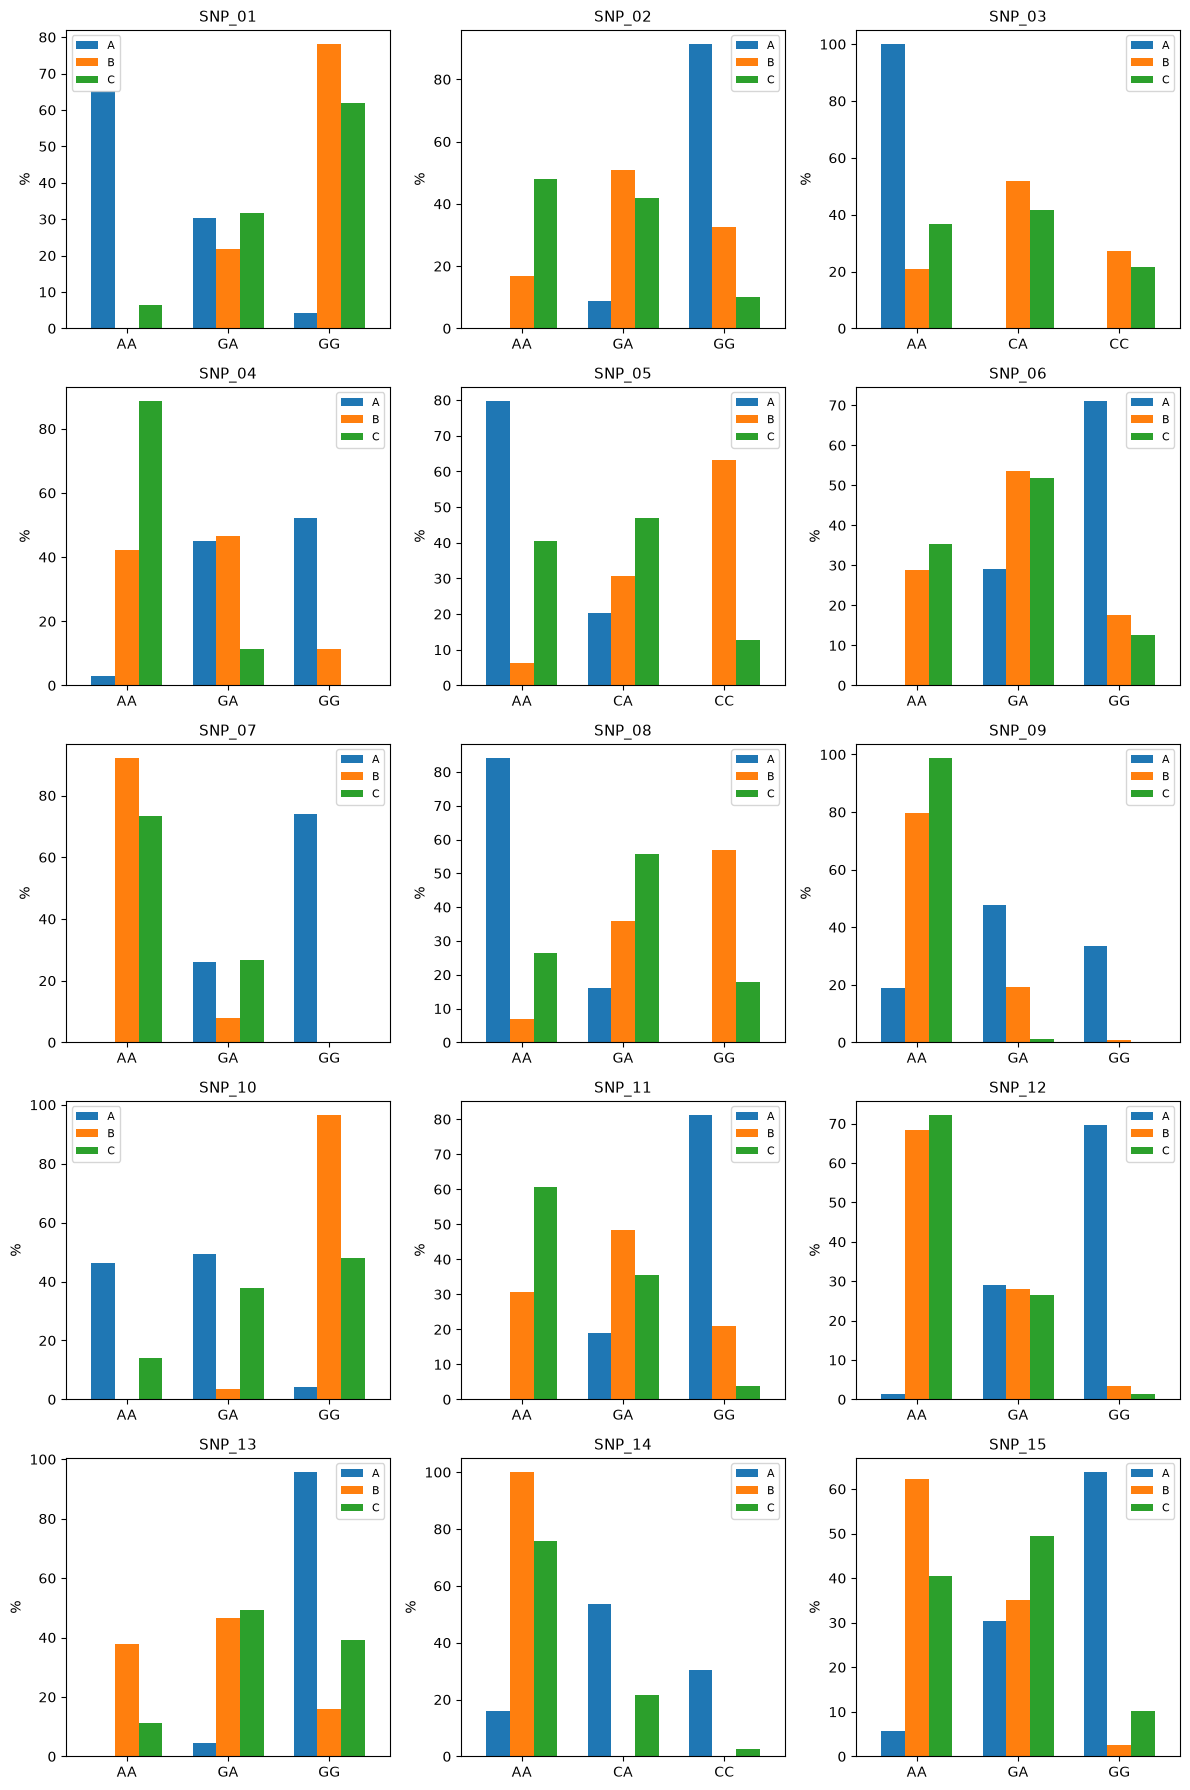

In [31]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(5, 3, figsize=(12, 18))
axes = axes.flatten()

for i, col in enumerate(snp_cols):
    
    table = pd.crosstab(
        df[col],
        df["class"],
        normalize="columns"
    ) * 100
    
    table = table.round(2)
    
    # 막대그래프
    table.plot(
        kind="bar",
        ax=axes[i],
        width=0.7
    )
    
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("%")
    axes[i].tick_params(axis="x", rotation=0)
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

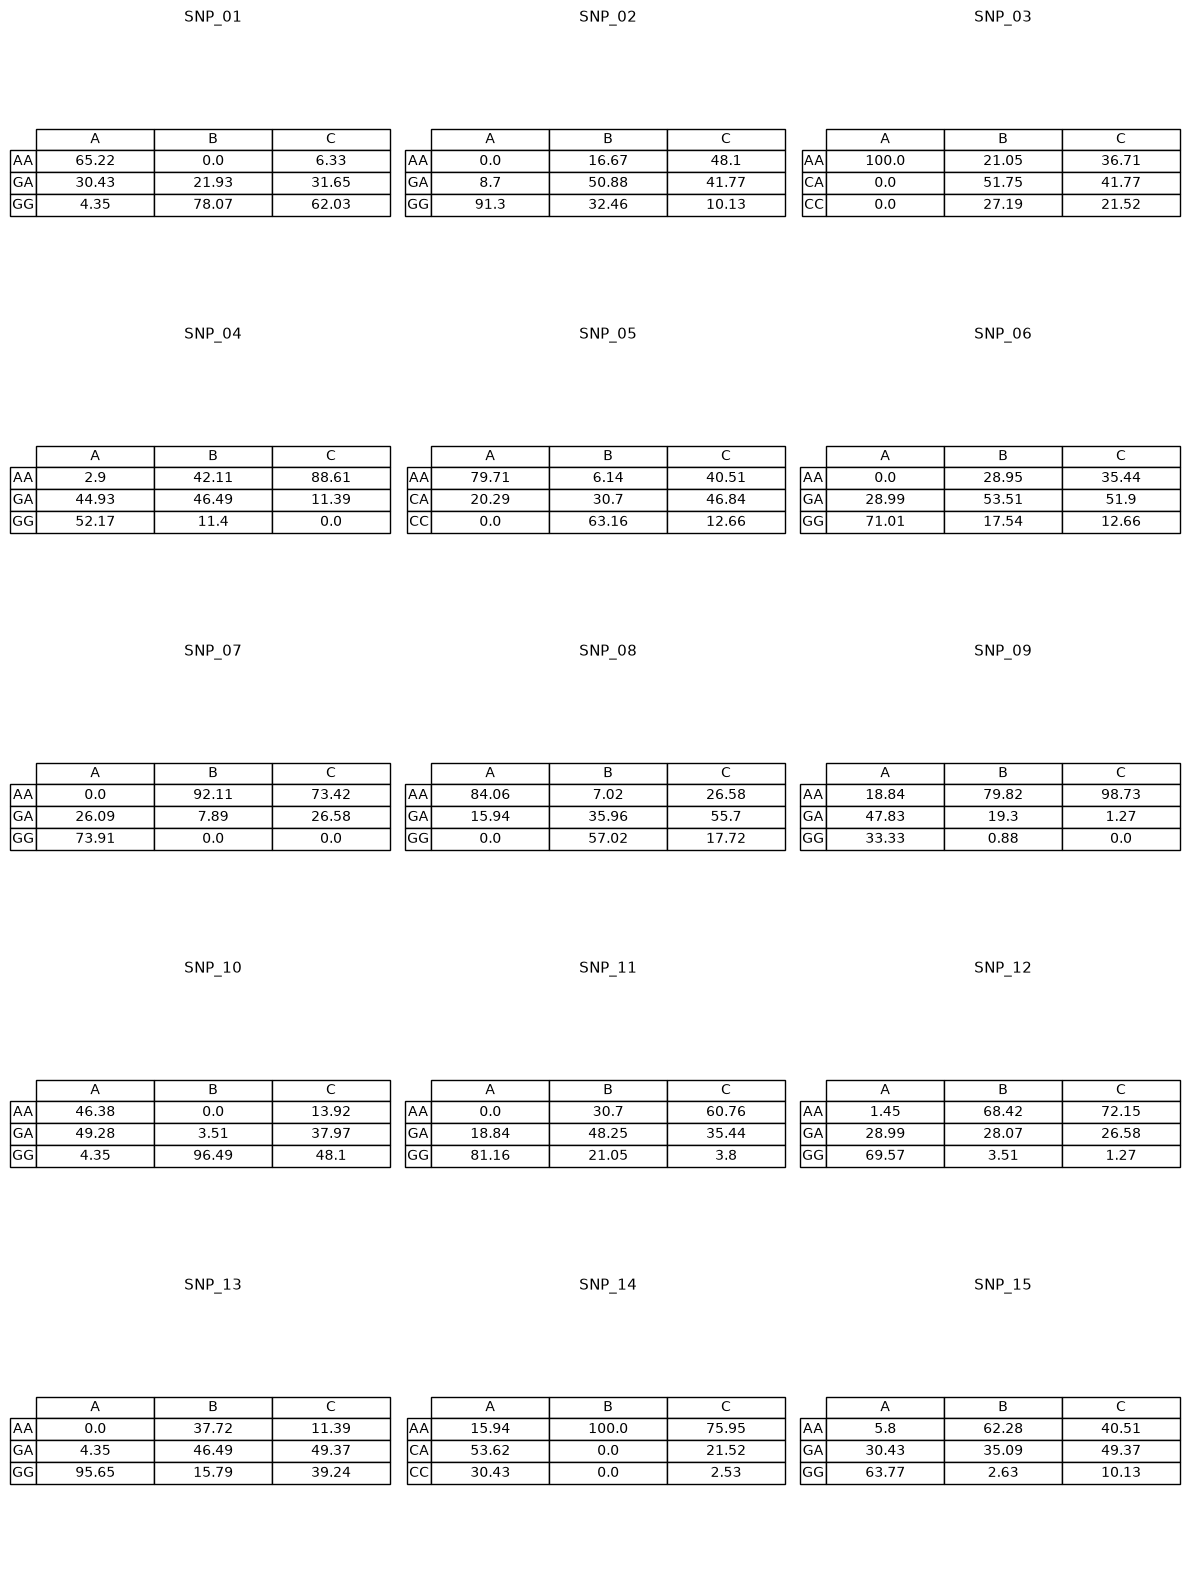

In [32]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(5, 3, figsize=(12, 16))
axes = axes.flatten()

for i, col in enumerate(snp_cols):

    table = pd.crosstab(
        df[col],
        df["class"],
        normalize="columns"
    ) * 100

    table = table.round(2)

    ax = axes[i]
    ax.axis("off")
    ax.set_title(col, fontsize=11, pad=8)

    ax.table(
        cellText=table.values,
        rowLabels=table.index,
        colLabels=table.columns,
        cellLoc="center",
        rowLoc="center",
        loc="center"
    )

# 남는 subplot 제거
for i in range(len(snp_cols), len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

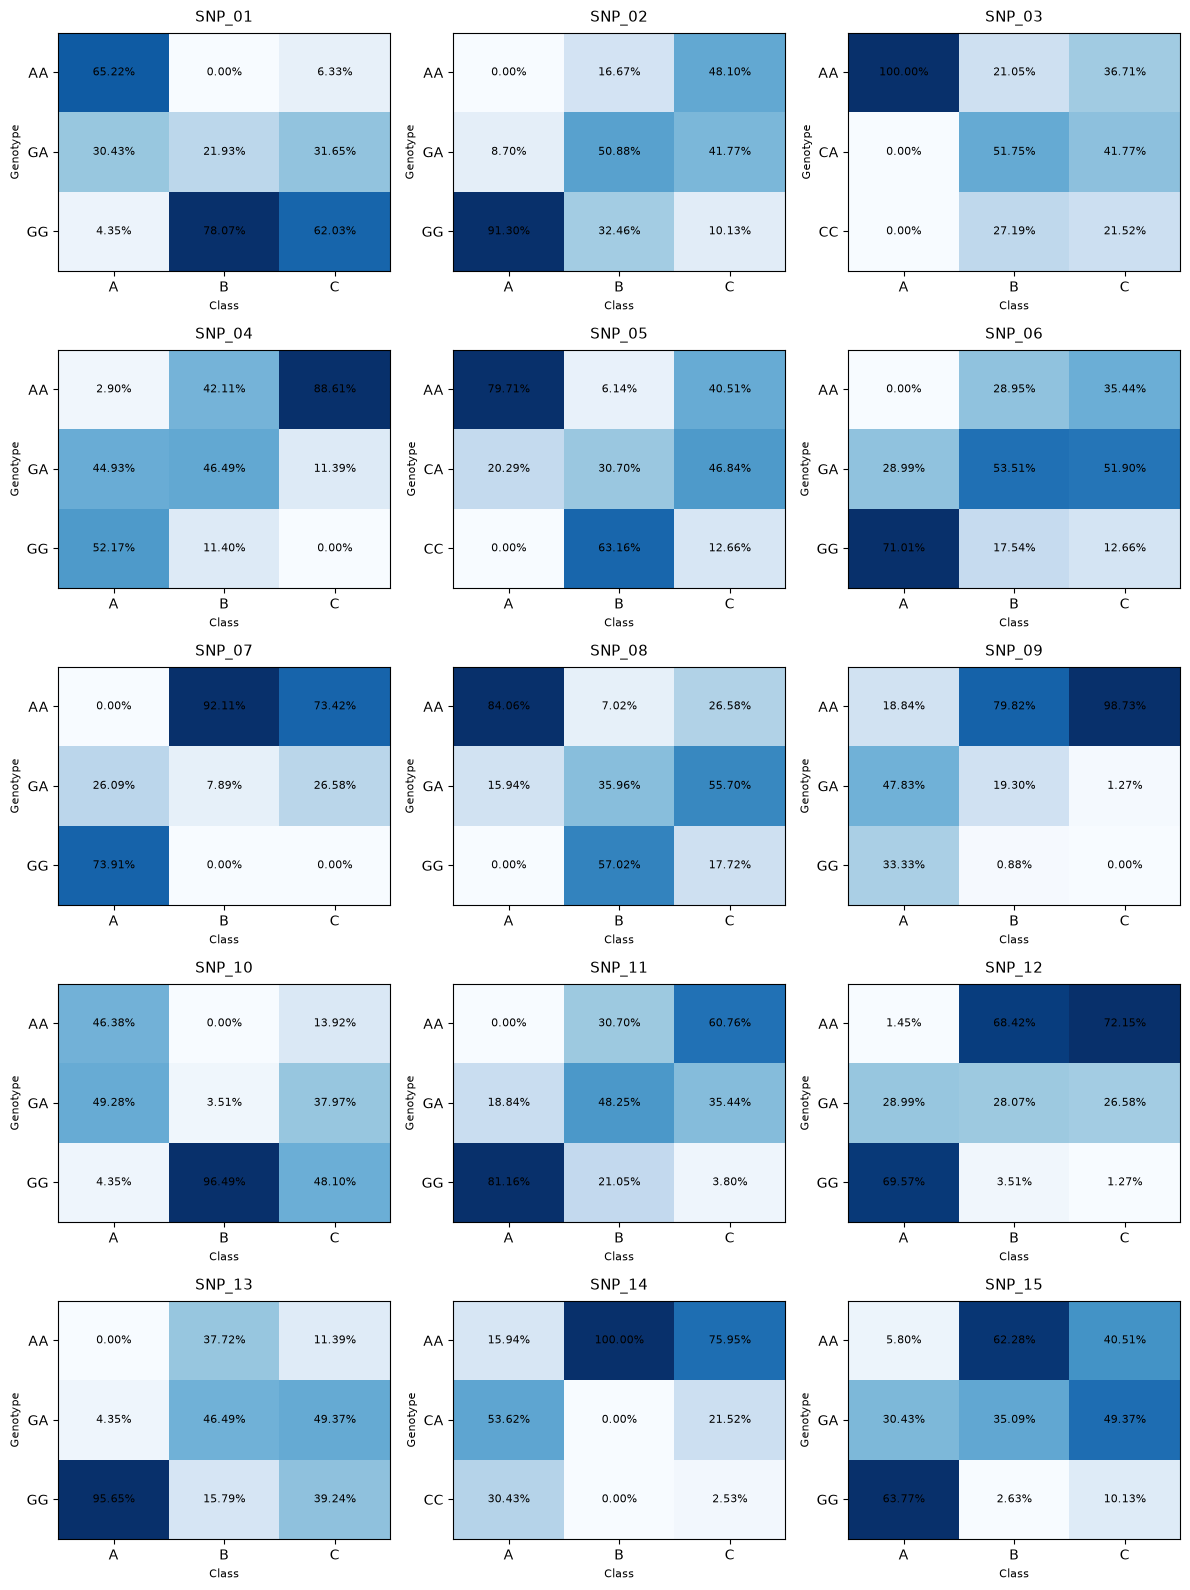

In [33]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(5, 3, figsize=(12, 16))
axes = axes.flatten()

for i, col in enumerate(snp_cols):

    table = pd.crosstab(
        df[col],
        df["class"],
        normalize="columns"
    ) * 100

    table = table.round(2)

    ax = axes[i]

    # 히트맵
    im = ax.imshow(
        table.values,
        cmap="Blues",
        aspect="auto"
    )

    # 제목
    ax.set_title(col, fontsize=11, pad=8)

    # 행/열 이름
    ax.set_xticks(range(len(table.columns)))
    ax.set_xticklabels(table.columns)

    ax.set_yticks(range(len(table.index)))
    ax.set_yticklabels(table.index)

    # 각 칸에 비율 표시
    for r in range(table.shape[0]):
        for c in range(table.shape[1]):
            ax.text(
                c, r,
                f"{table.iloc[r, c]:.2f}%",
                ha="center",
                va="center",
                fontsize=8
            )

    ax.set_xlabel("Class", fontsize=8)
    ax.set_ylabel("Genotype", fontsize=8)

# 남는 칸 제거
for i in range(len(snp_cols), len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

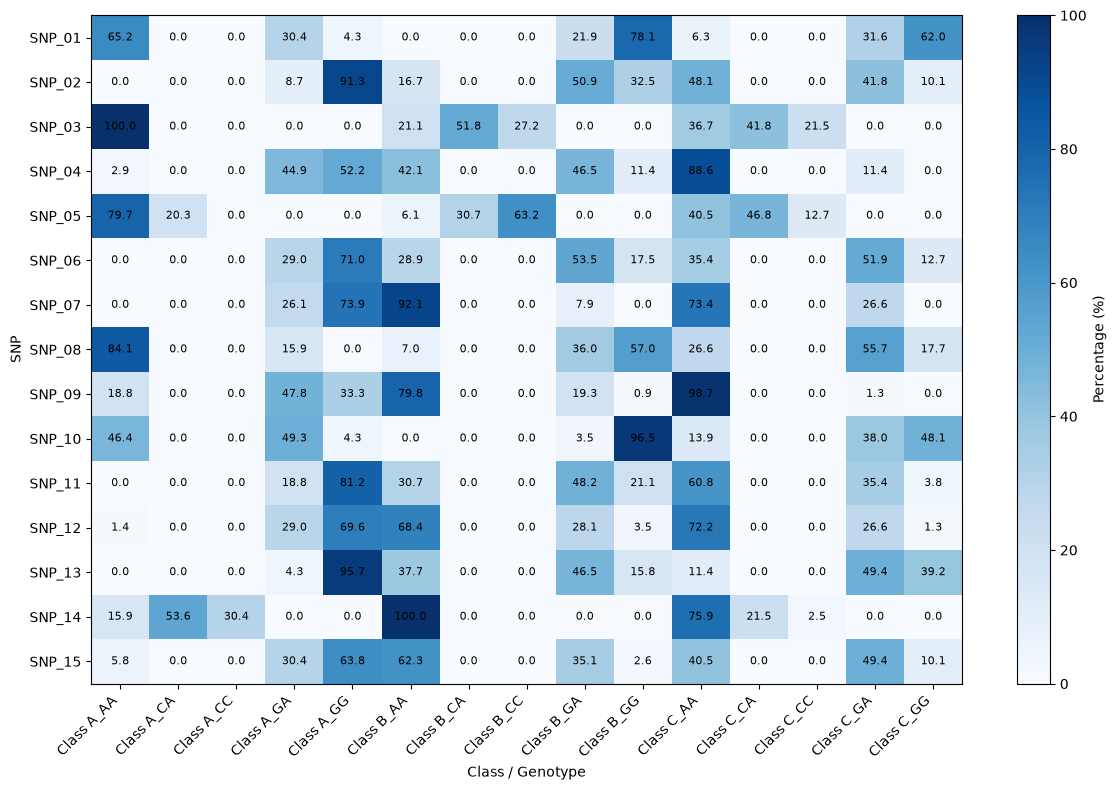

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

result = []

for col in snp_cols:

    table = pd.crosstab(
        df[col],
        df["class"],
        normalize="columns"
    ) * 100

    # class별 genotype 비율을 한 행으로
    row = {}

    for cls in table.columns:
        for genotype in table.index:
            row[f"Class {cls}_{genotype}"] = table.loc[genotype, cls]

    result.append(row)

heatmap_df = pd.DataFrame(result, index=snp_cols)

# 결측 조합은 0
heatmap_df = heatmap_df.fillna(0)

# 보기 좋은 열 순서
heatmap_df = heatmap_df.reindex(
    columns=sorted(heatmap_df.columns)
)

fig, ax = plt.subplots(figsize=(12, 8))

im = ax.imshow(
    heatmap_df,
    cmap="Blues",
    aspect="auto"
)

ax.set_yticks(range(len(heatmap_df)))
ax.set_yticklabels(heatmap_df.index)

ax.set_xticks(range(len(heatmap_df.columns)))
ax.set_xticklabels(
    heatmap_df.columns,
    rotation=45,
    ha="right"
)

# 숫자 표시
for i in range(heatmap_df.shape[0]):
    for j in range(heatmap_df.shape[1]):
        ax.text(
            j, i,
            f"{heatmap_df.iloc[i, j]:.1f}",
            ha="center",
            va="center",
            fontsize=8
        )

ax.set_xlabel("Class / Genotype")
ax.set_ylabel("SNP")

plt.colorbar(im, label="Percentage (%)")
plt.tight_layout()
plt.show()

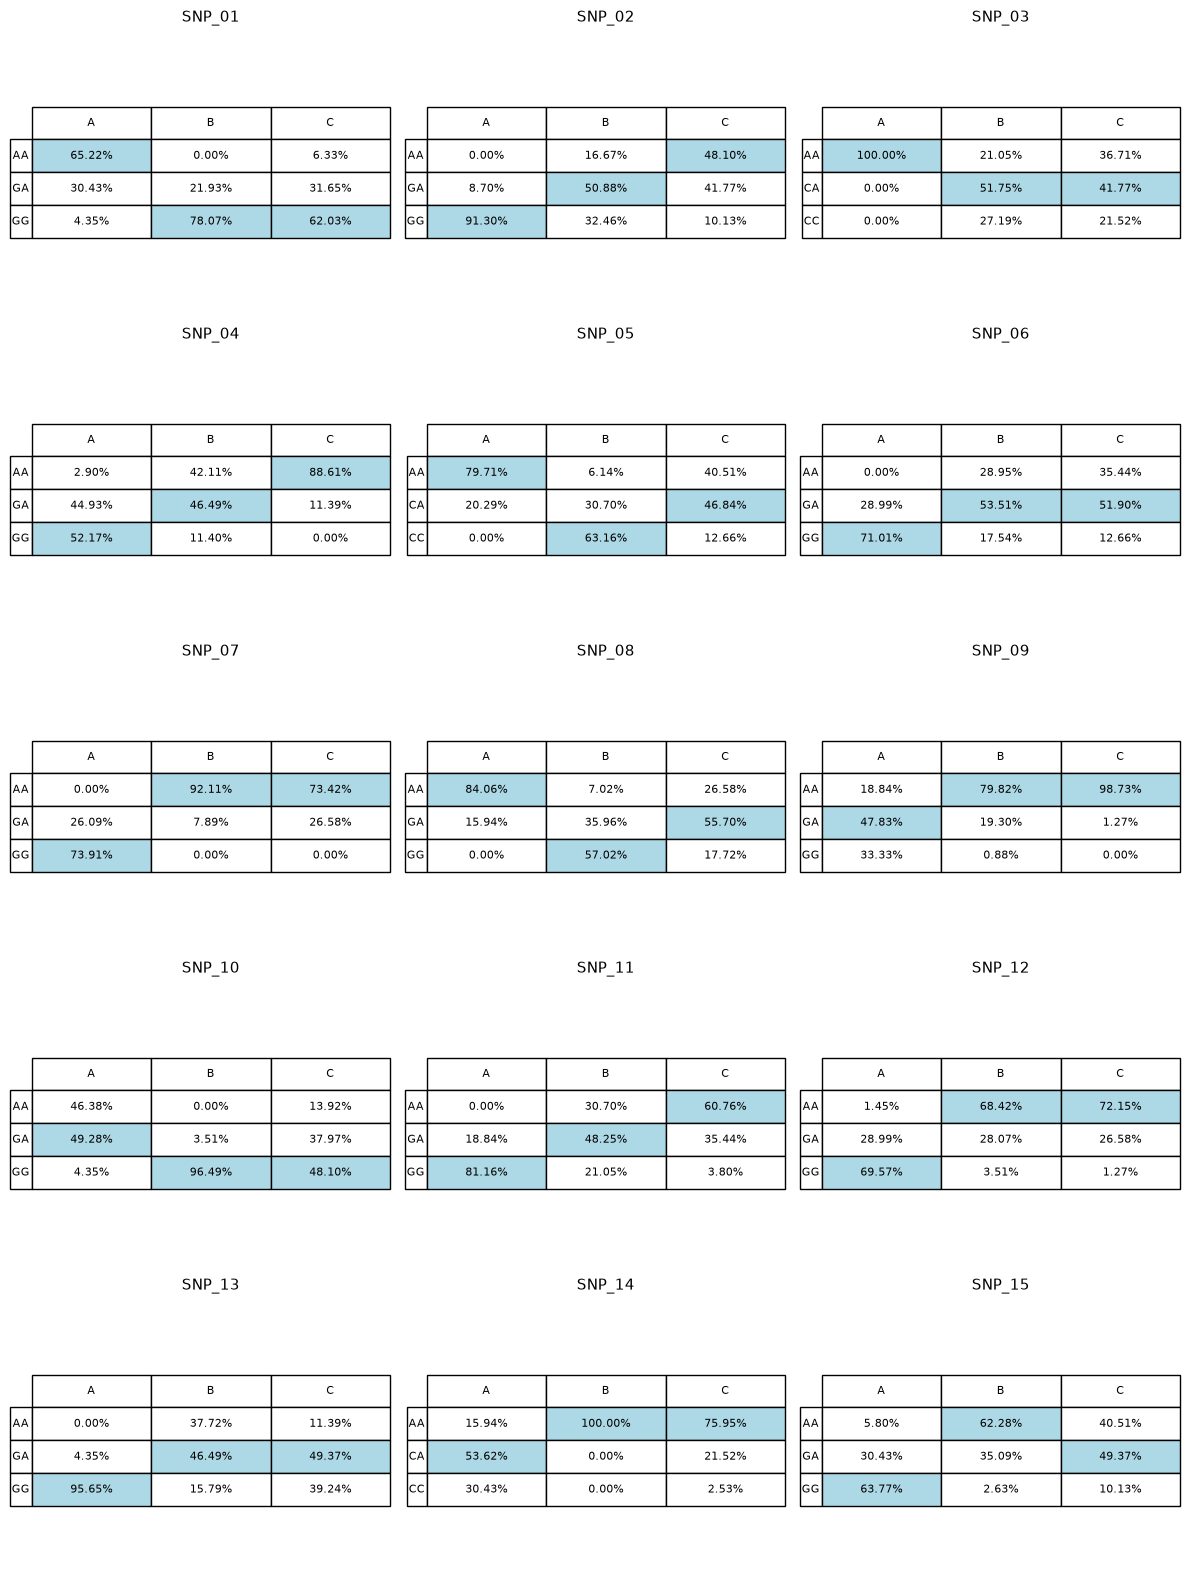

In [35]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(5, 3, figsize=(12, 16))
axes = axes.flatten()

for i, col in enumerate(snp_cols):

    # 비율 계산
    table = pd.crosstab(
        df[col],
        df["class"],
        normalize="columns"
    ) * 100

    # 소수점 2자리 + % 표시
    display_table = table.map(lambda x: f"{x:.2f}%")

    ax = axes[i]
    ax.axis("off")
    ax.set_title(col, fontsize=11, pad=8)

    tbl = ax.table(
        cellText=display_table.values,
        rowLabels=display_table.index,
        colLabels=display_table.columns,
        cellLoc="center",
        rowLoc="center",
        loc="center"
    )

    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8)
    tbl.scale(1, 1.5)

    # 각 Class별 가장 높은 비율에 색칠
    for c in range(table.shape[1]):
        max_row = table.iloc[:, c].values.argmax()
        tbl[(max_row + 1, c)].set_facecolor("lightblue")


# 남는 칸 제거
for i in range(len(snp_cols), len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [38]:
display(snp_info)

,SNP_id,name,chrom,cm,pos
0,SNP_01,BTA-19852-no-rs,2,67.05460,42986890
1,SNP_02,ARS-USMARC-Parent-DQ647190-rs29013632,6,31.15670,13897068
2,SNP_03,ARS-BFGL-NGS-117009,6,68.28920,44649549
3,SNP_04,ARS-BFGL-NGS-60567,6,77.87490,53826064
4,SNP_05,BovineHD0600017032,6,80.50150,61779512
5,SNP_06,BovineHD0600017424,6,80.59540,63048481
6,SNP_07,Hapmap49442-BTA-111073,6,80.78000,64037334
7,SNP_08,BovineHD0600018638,6,82.68560,67510588
8,SNP_09,ARS-BFGL-NGS-37727,6,86.87400,73092782
9,SNP_10,BTB-01558306,7,62.06920,40827112


In [39]:
snp_info_display = snp_info.copy()

snp_info_display.columns = [
    "SNP",
    "SNP 이름",
    "염색체",
    "유전적 위치(cM)",
    "물리적 위치(bp)"
]

display(snp_info_display)

,SNP,SNP 이름,염색체,유전적 위치(cM),물리적 위치(bp)
0,SNP_01,BTA-19852-no-rs,2,67.05460,42986890
1,SNP_02,ARS-USMARC-Parent-DQ647190-rs29013632,6,31.15670,13897068
2,SNP_03,ARS-BFGL-NGS-117009,6,68.28920,44649549
3,SNP_04,ARS-BFGL-NGS-60567,6,77.87490,53826064
4,SNP_05,BovineHD0600017032,6,80.50150,61779512
5,SNP_06,BovineHD0600017424,6,80.59540,63048481
6,SNP_07,Hapmap49442-BTA-111073,6,80.78000,64037334
7,SNP_08,BovineHD0600018638,6,82.68560,67510588
8,SNP_09,ARS-BFGL-NGS-37727,6,86.87400,73092782
9,SNP_10,BTB-01558306,7,62.06920,40827112


In [40]:
from scipy.stats import chi2_contingency

chi_results = []

for col in snp_cols:
    
    table = pd.crosstab(df[col], df["class"])
    
    chi2, p_value, dof, expected = chi2_contingency(table)
    
    chi_results.append({
        "SNP": col,
        "chi2": chi2,
        "p_value": p_value,
        "유의여부": "유의" if p_value < 0.05 else "비유의"
    })

chi_df = pd.DataFrame(chi_results)

display(
    chi_df.sort_values("p_value")
)

,SNP,chi2,p_value,유의여부
6,SNP_07,215.524791,1.721334e-45,유의
9,SNP_10,162.847454,3.582423e-34,유의
11,SNP_12,158.972064,2.428709e-33,유의
13,SNP_14,153.863394,3.024841e-32,유의
0,SNP_01,152.276281,6.620563e-32,유의
7,SNP_08,146.374615,1.217547e-30,유의
4,SNP_05,141.042445,1.688329e-29,유의
3,SNP_04,137.573031,9.336141e-29,유의
8,SNP_09,134.513329,4.216448e-28,유의
10,SNP_11,129.944323,4.002298e-27,유의


In [41]:
chi_df = chi_df.merge(
    snp_info,
    left_on="SNP",
    right_on="SNP_id",
    how="left"
)

display(
    chi_df.sort_values("p_value")
)

,SNP,chi2,p_value,유의여부,SNP_id,name,chrom,cm,pos
6,SNP_07,215.524791,1.721334e-45,유의,SNP_07,Hapmap49442-BTA-111073,6,80.78000,64037334
9,SNP_10,162.847454,3.582423e-34,유의,SNP_10,BTB-01558306,7,62.06920,40827112
11,SNP_12,158.972064,2.428709e-33,유의,SNP_12,Hapmap32827-BTA-146530,9,62.74630,55007839
13,SNP_14,153.863394,3.024841e-32,유의,SNP_14,Hapmap40256-BTA-84189,9,66.81970,72822507
0,SNP_01,152.276281,6.620563e-32,유의,SNP_01,BTA-19852-no-rs,2,67.05460,42986890
7,SNP_08,146.374615,1.217547e-30,유의,SNP_08,BovineHD0600018638,6,82.68560,67510588
4,SNP_05,141.042445,1.688329e-29,유의,SNP_05,BovineHD0600017032,6,80.50150,61779512
3,SNP_04,137.573031,9.336141e-29,유의,SNP_04,ARS-BFGL-NGS-60567,6,77.87490,53826064
8,SNP_09,134.513329,4.216448e-28,유의,SNP_09,ARS-BFGL-NGS-37727,6,86.87400,73092782
10,SNP_11,129.944323,4.002298e-27,유의,SNP_11,ARS-BFGL-NGS-44247,8,97.17310,92485682


In [42]:
X = df[snp_cols].copy()
y = df["class"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())
print(y.head())

X shape: (262, 15)
y shape: (262,)


,SNP_01,SNP_02,SNP_03,SNP_04,SNP_05,SNP_06,SNP_07,SNP_08,SNP_09,SNP_10,SNP_11,SNP_12,SNP_13,SNP_14,SNP_15
0,GG,GA,AA,GA,CA,AA,AA,GG,AA,GG,GA,AA,AA,AA,AA
1,GA,GA,CA,AA,AA,GA,AA,GA,AA,GA,AA,GA,GG,AA,AA
2,GG,GG,AA,GA,CC,GG,AA,GA,GA,GA,AA,AA,AA,AA,AA
3,AA,GG,AA,GA,AA,GG,GG,AA,GG,GA,GG,GG,GG,AA,GG
4,GG,GG,CC,AA,CC,AA,AA,AA,AA,GG,AA,AA,GA,AA,GA


0    B
1    C
2    B
3    A
4    C
Name: class, dtype: str
